Question 1: 

ist fachgerechte sondermüll entsorgung in zürich zu teuer, müsste die stadt zürich einen billigen entsorgungsdienst anbieten? korrelieren die anzahl illegal entsorgten abfälle mit dem steuerbaren Einkommen der Bevölkerung

In [45]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import datetime as dt

In [46]:
#Access and load the züri wie neu data via API

url_zwn = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Zueri_wie_neu?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=zwn_meldungen_p"
response_zwn = requests.get(url_zwn)
if response_zwn.status_code == 200:
    print("Data züri wie neu loaded sugessfull")
    zurich_zwn_gdf = gpd.read_file(response_zwn.url)
else:
    print("Data züri wie neu loading failed")

Data züri wie neu loaded sugessfull


In [47]:
url_neighbourhoods = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Quartiere?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statistische_quartiere_v"
response_neighbourhoods = requests.get(url_neighbourhoods)
if response_neighbourhoods.status_code == 200:
    print("Data neighbourhood loaded sugessfull")
    zurich_neighbourhoods_gdf = gpd.read_file(response_neighbourhoods.url)
else:
    print("Data neighbourhood loading failed")

Data neighbourhood loaded sugessfull


In [48]:

#Access and load the income data via API

url_income = 'https://data.stadt-zuerich.ch/api/3/action/datastore_search'
parameter_income = {"resource_id":"af01ed91-04f8-445b-8dfc-04cbf0a27e95", "limit":3000}
response_income = requests.get(url_income, params=parameter_income)
if response_income.status_code == 200:
    print("Data Income loaded sugessfull")

    #convert the json response into a dictionary (because the CKAN API returns a new dictionary where the data is in result and record)
    zurich_income_dic = response_income.json()["result"]["records"]
    #convert the dictionary into a dataframe
    zurich_income_df = pd.DataFrame(zurich_income_dic)
else:
    print("Data income loading failed")


Data Income loaded sugessfull


In [49]:

## filter income for the newest year

# display the current year
current_year = int(dt.date.today().year)

#filter dataframe for the newest year (always current year minus 3)
zurich_income_df = zurich_income_df[zurich_income_df["StichtagDatJahr"] == str(current_year -3)].copy()


In [ ]:
## create a mean for the 3 steuer tarife

#clean the data (drop na, convert to float)
zurich_income_df.dropna(subset=["SteuerEinkommen_p50"])
zurich_income_df["SteuerEinkommen_p50"] = zurich_income_df["SteuerEinkommen_p50"].astype(float)

#group by neigbourhoods and compute the mean income (of the 3 steuertarife) for each income
grouped_by_neighbourhoods_income = zurich_income_df.groupby("QuarLang", as_index=False)

zurich_mean_income_df = grouped_by_neighbourhoods_income[["SteuerEinkommen_p50"]].mean()
zurich_mean_income_df = zurich_mean_income_df.rename(columns={"SteuerEinkommen_p50": "mean_income", "QuarLang": "qname"})



,qname,mean_income
0,Affoltern,56.466667
1,Albisrieden,68.433333
2,Alt-Wiedikon,77.683333


In [ ]:
# Sort the züri wie neu data for waste and filter the columns



zurich_zwn_waste_gdf = zurich_zwn_gdf[zurich_zwn_gdf["service_name"]=="Abfall/Sammelstelle"]
zurich_zwn_waste_gdf_filtered = zurich_zwn_waste_gdf[["service_request_id", "title", "geometry"]].copy()
print(zurich_zwn_waste_gdf_filtered.info())



In [ ]:
#clean neighbourhoods file

zurich_neighbourhoods_gdf_filtered = zurich_neighbourhoods_gdf[["qname", "qnr", "geometry"]]

print(zurich_neighbourhoods_gdf_filtered.head(4))


In [ ]:

#join the trash points to the neighbourhoods

income_neighbourhood_trash_df = gpd.sjoin(zurich_zwn_waste_gdf_filtered, 
                                          merged_income_neighbourhoods,
                                          how="inner",
                                          predicate="within")

mask_groupby_neighbourhood = income_neighbourhood_trash_df.groupby("qname", as_index=False)

income_neighbourhood_trash_grouped_df = income_neighbourhood_trash_df[["qname"]].value_counts()

income_neighbourhood_trash_grouped_df.head(10)

qname       
Langstrasse     3873
Sihlfeld        3161
Hard            1636
Altstetten      1411
Alt-Wiedikon    1283
Unterstrass     1129
Seebach         1086
Werd             932
Wipkingen        921
Höngg            915
Name: count, dtype: int64

In [89]:
# merge the income to the neighbourhoods

final_data = pd.merge(left=income_neighbourhood_trash_grouped_df, 
                                        right=zurich_mean_income_df,
                                        left_on="qname",
                                        right_on="qname")
final_data = final_data.sort_values(by="mean_income", ascending=True)
final_data = final_data.set_index("qname")





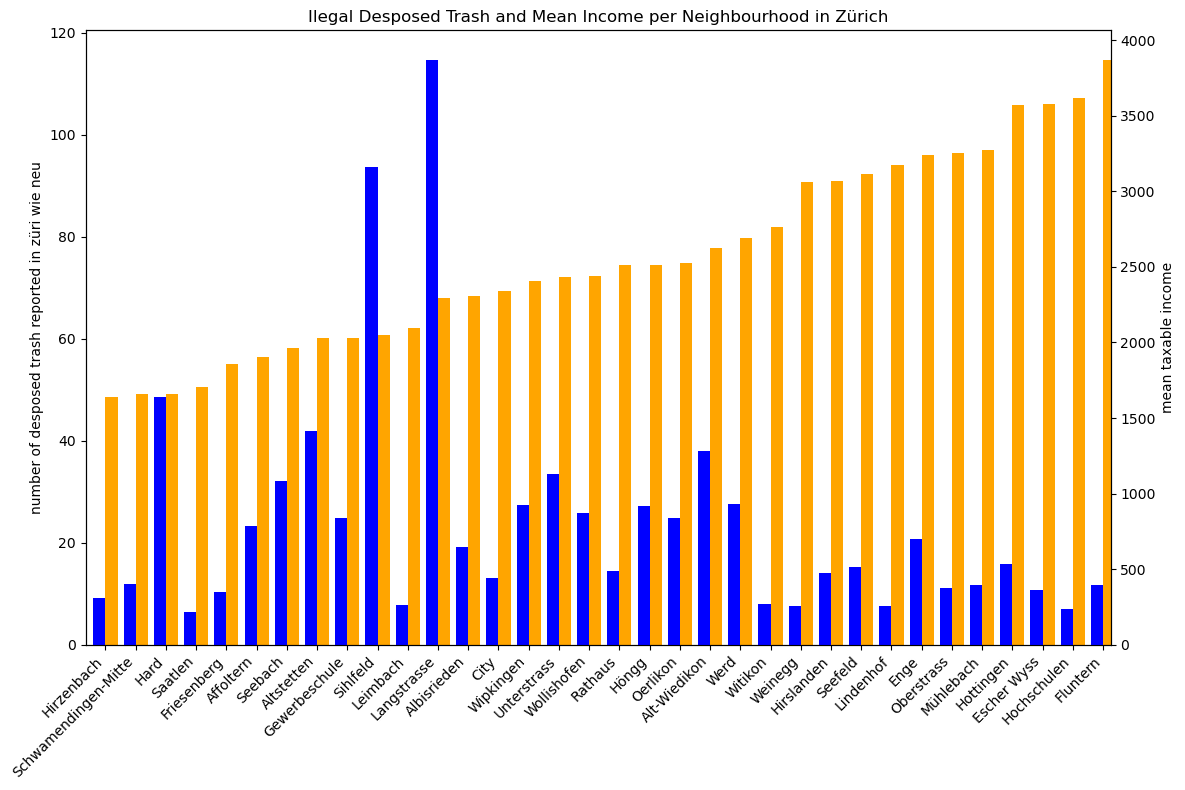

In [111]:
fig, ax1 = plt.subplots(figsize= (12,8))
ax2 = ax1.twinx()

final_data["mean_income"].plot(kind="bar", ax=ax1, width= 0.4, position=0, color= "orange",
                               title="Ilegal Desposed Trash and Mean Income per Neighbourhood in Zürich",
                               ylabel="number of desposed trash reported in züri wie neu",
                               xlabel="")
final_data["count"].plot(kind="bar", ax=ax2, width= 0.4, position=1, color= "blue",
                         ylabel="mean taxable income"
                         )
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, horizontalalignment="right")
plt.tight_layout()


plt.show()